# Plotting local coastal change using DEA Coastlines

## Plan
1. Select area of interest from DEACL WMS to load a geom object
2. Use geom to load DEACL WFS data
3. Plot a Hovmoller diagram from the area of interest

In [1]:
# load modules

from odc.ui import select_on_a_map
from ipyleaflet import basemaps, basemap_to_tiles, WMSLayer
from dea_tools.coastal import get_coastlines
import geopandas as gpd
import contextily as ctx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [56]:
# Select area of interest from WMS

WMS_URL = "https://geoserver.dea.ga.gov.au/geoserver/dea/wms"

basemap = basemap_to_tiles(basemaps.Esri.WorldImagery)

wms_shorelines = WMSLayer(
    url=WMS_URL,
    layers="dea:shorelines_annual",
    format="image/png",
    transparent=True,
    name="DEA Annual Shorelines",
    attribution="© Geoscience Australia",
)
wms_rates = WMSLayer(
    url=WMS_URL,
    layers="dea:rates_of_change",
    format="image/png",
    transparent=True,
    name="DEA Rates of Change",
    attribution="© Geoscience Australia",
)

geom = select_on_a_map(
    height="600px",
    layers=(basemap, wms_shorelines, wms_rates),
    # center=(-26, 135),
    # zoom=4,
    center=(-33.72, 151.29),   # Narrabeen Beach, NSW — change to your area
    zoom=4,
)
study_area = geom

Map(center=[-33.72, 151.29], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

In [57]:
# import DEA Coastlines for the area of interest
gdf = get_coastlines(study_area.boundingbox, layer="rates_of_change")
gdf3 = get_coastlines(study_area.boundingbox)

# Remove coastlines that are outside the desired extent

polygon_extent = gpd.GeoSeries(study_area.geom, crs="EPSG:4326").to_crs(gdf.crs)

gdf2 = gdf.clip(polygon_extent)
gdf3 = gdf3.clip(polygon_extent)


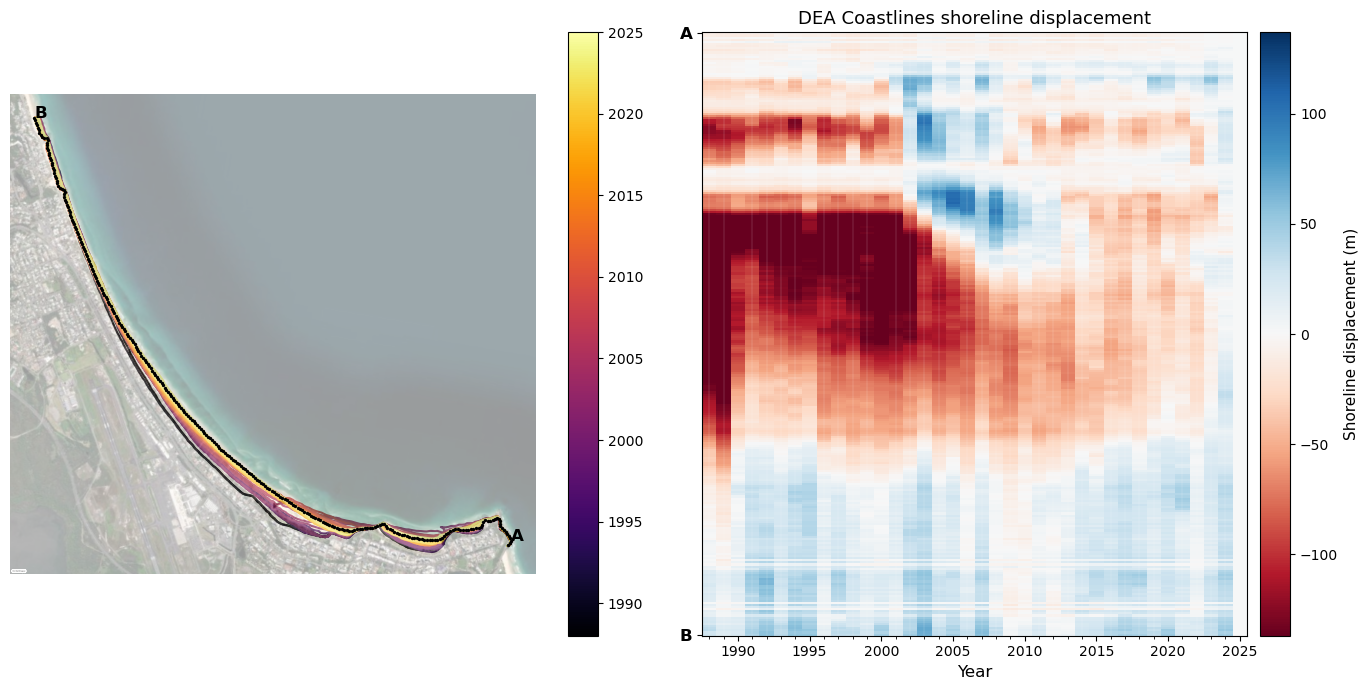

In [58]:
# Hovmoller time

rates_gdf = gdf2
rates_gdf = rates_gdf.sort_values("geometry", ascending=True)

# Plot 
fig, ax = plt.subplots(1,2, figsize=(14, 7))
# Plot the coastline of interest
gdf3.sort_values("year", ascending=True).plot(ax=ax[0], column="year", cmap="inferno", legend=True, zorder=0, alpha=1)
rates_gdf.geometry.plot(ax=ax[0], color="black", markersize=2, zorder=1)

# label the transect start and end points using points from rates_gdf
x_range = rates_gdf.geometry.x.max() - rates_gdf.geometry.x.min()
y_range = rates_gdf.geometry.y.max() - rates_gdf.geometry.y.min()

# Use the difference between x and y coordinates to determine which to use for transect A-->B
if x_range >= y_range:
    idx_a = rates_gdf.geometry.x.idxmax()
    idx_b = rates_gdf.geometry.x.idxmin()
    #Sort point values for the Hovmoller by x geometry
    rates_gdf["x_coord"] = rates_gdf.geometry.x
    rates_gdf = rates_gdf.sort_values("x_coord", ascending=True).drop(columns="x_coord")

    # Extract and order dist_* columns chronologically 
    dist_cols = sorted([c for c in rates_gdf.columns if c.startswith("dist_")],
                       key=lambda c: int(c.split("_")[1]))
    years = [int(c.split("_")[1]) for c in dist_cols]
    
    # Build the 2-D array (points × years) 
    Z = rates_gdf[dist_cols].values.astype(float)
else:
    idx_a = rates_gdf.geometry.y.idxmax()
    idx_b = rates_gdf.geometry.y.idxmin()
    # Sort point values for the Hovmoller by y geometry
    rates_gdf["y_coord"] = rates_gdf.geometry.y
    rates_gdf = rates_gdf.sort_values("y_coord", ascending=True).drop(columns="y_coord")
    # Extract and order dist_* columns chronologically 
    dist_cols = sorted([c for c in rates_gdf.columns if c.startswith("dist_")],
                       key=lambda c: int(c.split("_")[1]))
    years = [int(c.split("_")[1]) for c in dist_cols]
    
    # Build the 2-D array (points × years) 
    Z = rates_gdf[dist_cols].values.astype(float)

# Identify coordinates to label transect ends (A and B)
point_a = rates_gdf.geometry[idx_a]
point_b = rates_gdf.geometry[idx_b]

x_start, y_start = point_a.x, point_a.y
x_end,   y_end   = point_b.x, point_b.y

ax[0].text(x_start, y_start, "A", fontsize=12, fontweight="bold", color="black")
ax[0].text(x_end,   y_end,   "B", fontsize=12, fontweight="bold", color="black")

# Symmetric colour scale centred on zero 
abs_max = np.nanpercentile(np.abs(Z), 95)

# Add a basemap for context
ctx.add_basemap(
    ax=ax[0],
    source=ctx.providers.Esri.WorldImagery,
    crs="EPSG:3577",
    attribution="Esri WorldImagery",
    attribution_size=1,
    alpha=0.4,
)
# Plot the shoreline displacement Hovmoller plot for the coastline
pcm = ax[1].pcolormesh(
    years,
    np.arange(len(rates_gdf)),
    Z,
    cmap="RdBu",
    vmin=-abs_max,
    vmax=+abs_max,
    shading="nearest",
)

cbar = fig.colorbar(pcm, ax=ax[1], pad=0.02)
cbar.set_label("Shoreline displacement (m)", fontsize=11)

ax[1].set_xlabel("Year", fontsize=12)
ax[1].set_ylabel("Transect", fontsize=12)
ax[1].set_title("DEA Coastlines shoreline displacement", fontsize=13)
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(5))
ax[1].xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax[1].grid(axis="x", which="minor", color="white", linewidth=0.3, alpha=0.4)
ax[1].set_yticks([0, len(rates_gdf) - 1])
ax[1].set_yticklabels(["B", "A"], fontsize=12, fontweight="bold", color="black")

ax[0].axis('off')

plt.tight_layout()
# plt.savefig("hovmoller_dea_coastlines.png", dpi=150, bbox_inches="tight")
plt.show()